In [1]:
import os
import glob
import sys
import tempfile
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.signal import convolve2d

import rasterio.features
import rasterio
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, Resampling

sys.path.append("../utils")

import config
import data_utils
import planet_api
import planet_utils

geodetic = "EPSG:4326"
mercator = "EPSG:3857"
mollweide = "ESRI:54009"

In [3]:
PLANET_API_KEY = planet_api.key
planet = planet_utils.PlanetAPI(PLANET_API_KEY, planet_utils.basemap_url)
mosaic_names = planet.get_mosaics()

mosaic_names = [name for name in mosaic_names if "monthly" in name]
mosaic_names

['global_monthly_2016_01_mosaic',
 'global_monthly_2016_02_mosaic',
 'global_monthly_2016_03_mosaic',
 'global_monthly_2016_04_mosaic',
 'global_monthly_2016_05_mosaic',
 'global_monthly_2016_06_mosaic',
 'global_monthly_2016_07_mosaic',
 'global_monthly_2016_08_mosaic',
 'global_monthly_2016_09_mosaic',
 'global_monthly_2016_10_mosaic',
 'global_monthly_2016_11_mosaic',
 'global_monthly_2016_12_mosaic',
 'global_monthly_2017_01_mutate_mosaic',
 'global_monthly_2017_02_mosaic',
 'global_monthly_2017_03_mosaic',
 'global_monthly_2017_04_mosaic',
 'global_monthly_2017_05_mosaic',
 'global_monthly_2017_06_mosaic',
 'global_monthly_2017_07_mosaic',
 'global_monthly_2017_08_mosaic',
 'global_monthly_2017_09_mosaic',
 'global_monthly_2017_10_mosaic',
 'global_monthly_2017_11_mosaic',
 'global_monthly_2017_12_mosaic',
 'global_monthly_2018_01_mosaic',
 'global_monthly_2018_02_mosaic',
 'global_monthly_2018_03_mosaic',
 'global_monthly_2018_04_mosaic',
 'global_monthly_2018_05_mosaic',
 'globa

In [4]:
# mosaic = "global_monthly_2022_12_mosaic"
mosaic_names = ["global_monthly_2022_12_mosaic"]

In [15]:
counties = gpd.read_file("/capstone/wildfire_prep/data/ca_counties/CA_Counties.shp")
counties = counties.to_crs(geodetic)
sb_county = counties.loc[counties["NAME"] == "Santa Barbara"]
bbox = [-125, 34.25, -119.0, 38.0]
sb_county = sb_county.clip(bbox)
sb_county.boundary.plot()



NameError: name 'geodetic' is not defined

In [9]:
sb_grid = data_utils.create_grid(
    sb_county,
    resolution=0.01,
    geometry_col="geometry",
    id_col="NAME",
    return_ids=True,
)
sb_grid_gdf = gpd.GeoDataFrame(
    sb_grid,
    geometry=gpd.points_from_xy(sb_grid.lon, sb_grid.lat),
    crs="EPSG:4326",
)
sb_grid_gdf.geometry = sb_grid_gdf.geometry.buffer(0.005, cap_style=3)

print(f"Shape (row, col): {sb_grid_gdf.shape}")

sb_grid_gdf.head()

NameError: name 'sb_county' is not defined

In [10]:
basemap_dir = "../../data/basemaps"

planet.set_mosaic(mosaic_names[0])
bbox_aoi = sb_county.geometry.total_bounds
all_items = planet.get_items(bbox_aoi)
quad_df = planet.convert_items_to_geodataframe(all_items)
quad_df = quad_df.drop_duplicates(subset="id")

quad_df = quad_df.sjoin(sb_county, predicate="intersects")
quad_df.drop(columns=["index_right"], inplace=True)
quad_df.head()

NameError: name 'sb_county' is not defined

NameError: name 'quad_df' is not defined

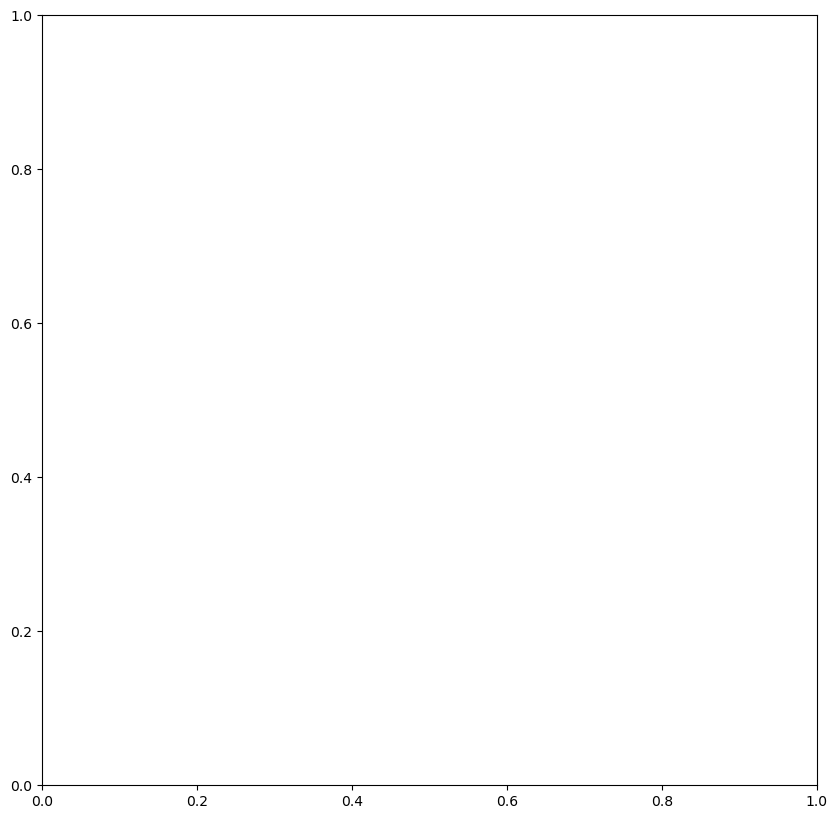

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))

quad_df.boundary.plot(ax=ax, edgecolor="grey", color="deepskyblue")
sb_county.plot(ax=ax, color="None", edgecolor="black")

plt.show()

In [14]:
intersecting = gpd.sjoin(
    sb_grid_gdf.reset_index(),
    quad_df,
    how="left",
    predicate="intersects",
)

sb_grid_gdf["id"] = intersecting.groupby("index")["id"].apply(list).values

sb_grid_gdf = sb_grid_gdf[
    ~sb_grid_gdf["id"].apply(data_utils.contains_nan)
]

sb_grid_gdf = sb_grid_gdf.to_crs(mercator)

file_dir = os.path.join(basemap_dir, mosaic_names[0], "quad_ids")
os.makedirs(file_dir, exist_ok=True)

quad_fn = os.path.join(file_dir, "quad_ids.geojson")
quad_df.to_file(quad_fn, driver="GeoJSON")

grid_fn = os.path.join(file_dir, "sb_grid_gdf.parquet")
sb_grid_gdf.to_parquet(grid_fn)

NameError: name 'sb_grid_gdf' is not defined

In [13]:
for mosaic in sorted(mosaic_names, reverse=True):
    print(f"Processing {mosaic}...", end="\n")
    mosaic_dir = basemap_dir + "/" + mosaic
    quad_dir = mosaic_dir + "/basemap_quads"
    quad_id_fp = mosaic_dir + "/quad_ids/quad_ids.geojson"

    quad_df = gpd.read_file(quad_id_fp, driver="GeoJSON")

    quad_ids_list = quad_df.id.tolist()

    os.makedirs(quad_dir, exist_ok=True)
    existing_files = os.listdir(quad_dir)

    filtered_quad_ids_list = planet_utils.filter_existing_quad_ids(
        quad_ids_list, existing_files
    )
    chunked_quad_id_list = planet_utils.chunk_list(filtered_quad_ids_list, 100)

    print(f"N Quads: {len(quad_ids_list)}")
    print(f"N Quads Remaining: {len(filtered_quad_ids_list)}")
    print(f"N Chunks: {len(chunked_quad_id_list)}")

    for i in range(len(chunked_quad_id_list)):
        print(f"Chunk: {i + 1}/{len(chunked_quad_id_list)}", end="\n")

        order_params = {
            "name": "Basemap order with geometry",
            "source_type": "basemaps",
            "order_type": "partial",
            "products": [
                {
                    "mosaic_name": mosaic,
                    "quad_ids": chunked_quad_id_list[i],
                }
            ],
        }

        order = planet.place_order(order_params)

        print("Polling for order success...", end="\n")

        planet.poll_for_success(order, loop_time=10, num_loops=240)

        results = planet.get_results(order)

        planet.download_results(
            results,
            directory=basemap_dir,
            overwrite=False,
            show_progress=True,
            max_retries=5,
        )

        # print("Organizing files...", end="\n")

        # planet.organize_files(
        #     base_dir=basemap_dir,
        #     mosaic_name=mosaic,
        #     overwrite=False,
        #     verbose=False,
        # )

        print("Done!", end="\n\n")

Processing global_monthly_2022_12_mosaic...


DataSourceError: ../../data/basemaps/global_monthly_2022_12_mosaic/quad_ids/quad_ids.geojson: No such file or directory

In [ ]:
image_dir = os.path.join(basemap_dir, mosaic_names[0], "basemap_quads")

image = os.listdir(image_dir)[0]

image_path = os.path.join(image_dir, image)

image_path

'../../data/basemaps/global_monthly_2022_12_mosaic/basemap_quads/344-1232_quad.tif'

In [ ]:


with rasterio.open(image_path) as src:
    rast = src.read([1, 2, 3])

print(f"""
Shape: {rast.shape}
CRS: {src.crs}
Driver: {src.driver}
Data type: {src.dtypes[0]}
Dataset name: {src.name}
Bounds: {src.bounds}
Data sample: 
{rast[:1]}
""")


Shape: (3, 4096, 4096)
CRS: EPSG:3857
Driver: GTiff
Data type: uint8
Dataset name: ../../data/basemaps/global_monthly_2022_12_mosaic/basemap_quads/344-1232_quad.tif
Bounds: BoundingBox(left=-13306157.882029148, bottom=4070118.8815700314, right=-13286590.00279086, top=4089686.760808319)
Data sample: 
[[[ 75 132 144 ... 174 165 143]
  [131 136 109 ... 182 199 202]
  [191 132  89 ... 174 191 217]
  ...
  [ 12  17  19 ...  14  25  22]
  [ 26  19  19 ...  21  28  26]
  [ 29  22  20 ...  33  30  30]]]



In [ ]:

def read_and_downscale(image_path, downscale_factor=10):
    with rasterio.open(image_path) as src:
        # Initialize an empty array to hold the downscaled data
        downscaled_data = np.zeros(
            (3, int(src.height / downscale_factor), int(src.width / downscale_factor)),
            dtype=src.meta["dtype"],
        )

        # Iterate over the first three bands and downscale each
        for band in range(1, 4):  # Bands 1, 2, 3 (Blue, Green, Red)
            data = src.read(
                band,
                out_shape=(
                    1,
                    int(src.height / downscale_factor),
                    int(src.width / downscale_factor),
                ),
                resampling=Resampling.bilinear,
            )
            downscaled_data[band - 1, :, :] = data

    return downscaled_data

In [ ]:
# List to keep track of paths to the downscaled images
downscaled_image_paths = []
for idx, row in tqdm(
    quad_df.iterrows(), total=quad_df.shape[0], desc="Processing Images"
):
    image_path = os.path.join(quad_dir, f"{row['id']}_quad.tif")
    downscaled_image = read_and_downscale(image_path)

    # Open the original image to get its metadata
    with rasterio.open(image_path) as src:
        meta = src.meta.copy()
        # Update metadata for the downscaled image
        meta.update(
            {
                "driver": "GTiff",
                "height": downscaled_image.shape[1],
                "width": downscaled_image.shape[2],
                "count": 3,  # Number of bands
                "dtype": downscaled_image.dtype,
                "transform": src.transform
                * src.transform.scale(
                    (src.width / downscaled_image.shape[2]),
                    (src.height / downscaled_image.shape[1]),
                ),
            }
        )

    # Save the downscaled image as a temporary file
    with tempfile.NamedTemporaryFile(delete=False, suffix=".tif") as temp_file:
        temp_file_path = temp_file.name

        # Save using rasterio
        with rasterio.open(temp_file_path, "w", **meta) as dst:
            dst.write(downscaled_image)

        downscaled_image_paths.append(temp_file_path)
        


Processing Images: 100%|██████████| 43/43 [00:00<00:00, 75.41it/s]


In [ ]:
# Use rasterio to merge the temporary files
with rasterio.open(downscaled_image_paths[0]) as src0:
    meta = src0.meta.copy()

# Create a mosaic
mosaic, out_trans = merge(downscaled_image_paths, method="first")


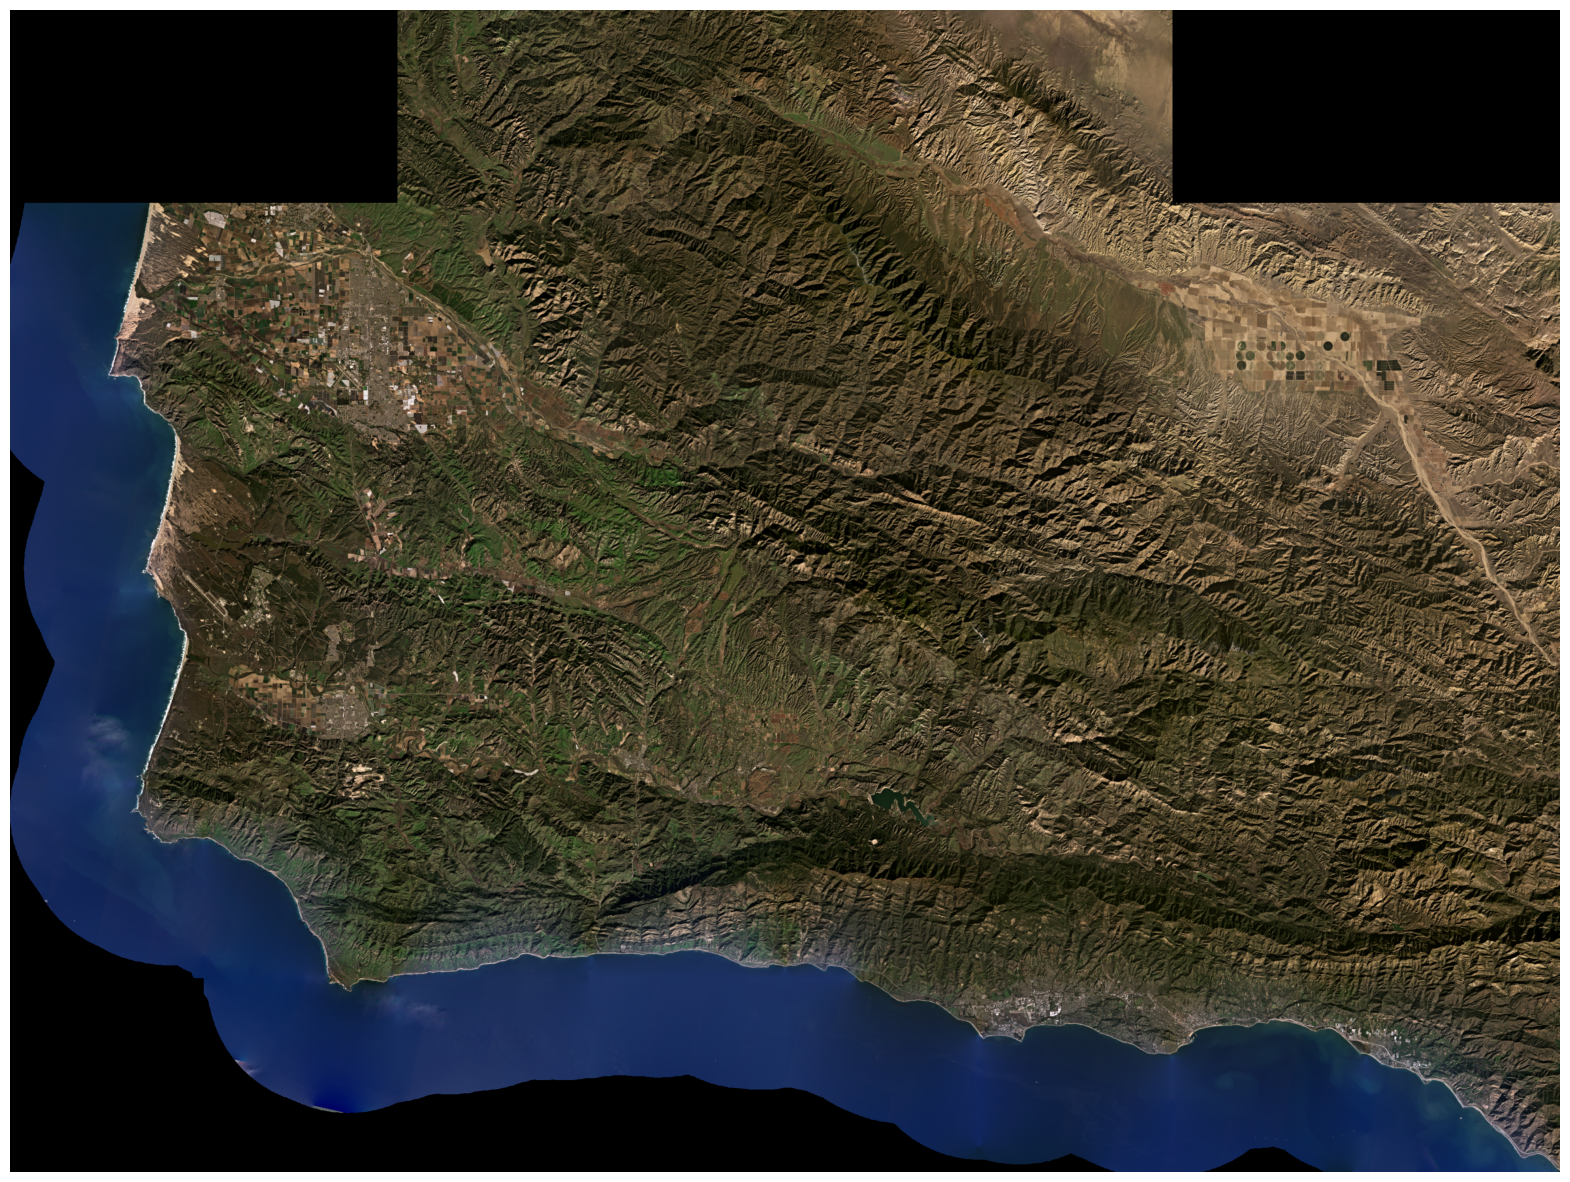

In [ ]:
# Clean up temporary files
for temp_file_path in downscaled_image_paths:
    os.remove(temp_file_path)
fig, ax = plt.subplots(figsize=(20, 20))
ax.imshow(mosaic.transpose((1, 2, 0)))
ax.axis("off")
plt.show()

In [ ]:
data_dir = os.path.join("/capstone", "wildfire_prep", "data-preparation", "planet_download", "data")

parcel_fp = os.path.join(
    data_dir, "parcel_data", "Defensible_Space_2024_address_points.gdb"
)

parcel_data = gpd.read_file(parcel_fp)

parcel_data.geometry = gpd.points_from_xy(parcel_data._longitude, parcel_data._latitude)

parcel_data


/Users/ryangreen/.conda/envs/prg/lib/python3.12/site-packages/pyogrio/geopandas.py:265: UserWarning: More than one layer found in 'Defensible_Space_2024_address_points.gdb': 'T2024_Defensible_Space_LatLong_Addr' (default), 'T2024_Defensible_Space_LatLong_Addr_Points', 'c2024_Defensible_Space_LatLong_Addr_XYTableToPoint'. Specify layer parameter to avoid this warning.
  result = read_func(
/tmp/ipykernel_5314/1291756682.py:9: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  parcel_data.geometry = gpd.points_from_xy(parcel_data._longitude, parcel_data._latitude)


,_latitude,_longitude,address
0,34.713144,-120.111912,4551 Figueroa Mountain Rd Santa Ynez CA 93441 US
1,34.711830,-120.111129,4551 Figueroa Mountain Rd Santa Ynez CA 93441 US
2,34.747729,-120.028376,7445 Figueroa Mountain Rd Santa Ynez CA 93460 US
3,34.747324,-120.027858,7445 Figueroa Mountain Rd Santa Ynez CA 93460 US
4,34.746687,-120.028255,7445 Figueroa Mountain Rd Santa Ynez CA 93460 US
...,...,...,...
14879,34.686215,-119.902500,9500 Happy Canyon Rd Santa Ynez CA 93460 US
14880,34.686091,-119.903605,9500 Happy Canyon Rd Santa Ynez CA 93460 US
14881,34.687801,-119.902894,9500 Happy Canyon Rd Santa Ynez CA 93460 US
14882,34.728377,-119.991868,9000 Figueroa Mountain Rd Santa Ynez CA 93460 US


In [ ]:
inspection_fp = os.path.join(
    data_dir,
    "inspections_data",
    "2022_defensible_space_inspections_SBC",
    "2022_defensible_space_inspections_SBC.shp",
)

pd.set_option('display.max_columns', None)

inspection_2022 = gpd.read_file(inspection_fp)
inspection_2022.head()

,fulcrum_id,created_at,updated_at,system_cre,system_upd,version,status,project,assigned_t,latitude,longitude,report_tit,globalid,keyid,propertyst,inspection,inspectorp,inspecti_1,addressvis,address_su,address_th,address__1,address_lo,address__2,address_ad,address_po,address_co,address_fu,calfireuni,county,community,community_,battalion,enginenumb,stationnam,shift,shift_juli,accessegre,occupantho,deliveryno,inspecti_2,a_removebr,b_removele,c_removede,d_removede,e_removefl,f_removefl,g_relocate,h_cutannua,i_removefu,j_exposedw,k_removede,l_removelo,m_outbuild,n_displaya,o_stovepip,recommendc,waterstora,water_sour,can_engine,water_stor,water_comm,structuret,structureh,roofconstr,eaves,ventscreen,exteriorsi,windowpane,deckporchg,deckporche,patiocover,fenceattac,propanetan,utilitymis,utilitym_1,nonhabitab,escalateto,reinspecti,citationnu,number_of_,photoid,photoid_ca,le100numbe,inspecti_3,coredata,firescopei,apn,yearbuilt,siteaddres,numberofst,appenddate,editstatus,calculated,calculat_1,calculat_2,textfield1,textfield2,numberfiel,numberfi_1,previousyr,previous_1,calculat_3,calculat_4,creationda,editdate,creator,editor,Date,geometry
0,48c58877-f0ce-438d-ac87-6434a2c15fe8,2022-02-14 10:44:17 PST,2022-05-24 12:22:14 PDT,2022-02-14 10:44:17 PST,2022-05-24 12:22:23 PDT,8.0,Compliant,None,None,34.461625,-119.772555,Defensible Space Inspection Report,None,NaN,None,None,Engine,2022-05-24,Yes - Without Reflective,4440,Shadow Hills Cir,None,Santa Barbara,Santa Barbara,CA,93105,US,4440 Shadow Hills Cir Santa Barbara Santa Barb...,SBC,SBA,San Marcos Foothills,None,1,NaN,13,A,144,Yes,No,Mailed,15,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,yes,Hydrant- Municipal/Public Water Supply,yes,None,None,Multi Family Residence Multi Story,Habitable,Tile,Enclosed,"Mesh Screen <= 1/8""",Other,Single Pane,Masonry/Concrete,Masonry/Concrete,Non Combustible,No Fence,Not Applicable,None,0,0,None,None,None,0.0,"eb994fe9-6273-444c-95b7-c3633b0876f5,de1dc62a-...",",,",NaN,NaN,None,None,None,NaN,None,NaN,None,None,None,None,None,None,None,NaN,NaN,None,None,None,None,2022-02-14,2022-02-14,None,None,2022-05-24,POINT (-119.77256 34.46163)
1,2f9d4c7c-54cb-415d-aae4-57f9b6c18994,2022-02-28 16:11:51 PST,2022-10-25 11:33:18 PDT,2022-02-28 16:11:51 PST,2022-10-25 11:34:34 PDT,6.0,Compliant,None,None,34.446105,-119.720859,Defensible Space Inspection Report,None,NaN,None,None,DSI,2022-10-25,Yes - Without Reflective,2928,La Combadura Rd,None,Santa Barbara,Santa Barbara,CA,93105,US,2928 La Combadura Rd Santa Barbara Santa Barba...,SBC,SBA,Mission Canyon,None,1,NaN,15,C,298,Yes,No,Email,15,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,yes,Hydrant- Municipal/Public Water Supply,yes,None,None,Single Family Residence Single Story,Habitable,Asphalt,Unenclosed,"Mesh Screen <= 1/8""",Stucco/Brick/Cement,Multi Pane,No Deck/Porch,No Deck/Porch,No Patio Cover/Carport,Not Observed,Not Applicable,<30',1,None,None,None,None,0.0,None,None,NaN,NaN,None,None,None,NaN,None,NaN,None,None,None,None,None,None,None,NaN,NaN,None,None,None,None,2022-02-28,2022-02-28,None,None,2022-10-25,POINT (-119.72086 34.4461)
2,f351800c-fc5c-4b79-bf24-a41775b74d7c,2022-04-05 13:47:06 PDT,2022-09-05 13:47:11 PDT,2022-04-05 13:47:06 PDT,2022-09-05 13:55:48 PDT,4.0,Compliant,None,None,34.672591,-120.108711,Defensible Space Inspection Report,None,0.0,None,None,DSI,2022-08-31,Yes - Without Reflective,3110 A,Acampo Rd,None,Santa Ynez,Santa Barbara,CA,93441,US,3110 A Acampo Rd Santa Ynez Santa Barbara CA 9...,SBC,SBA,Los Olivos,None,3,32.0,Santa Ynez Valley (Outside Engine Co. Area),C,248,Yes,No,Hardcopy,15,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,yes,Hydrant- Municipal/Public Water Supply,yes,None,None,Single Family Residence Single Story,Habitable,Tile,Unenclosed,No Vents,Stucco/Brick/Cement,Single Pane,Masonry/Concrete,No Deck/Porch,Combustible,Combustible,Not Applicable,None,0,0,None,None,None,0.0,None,None

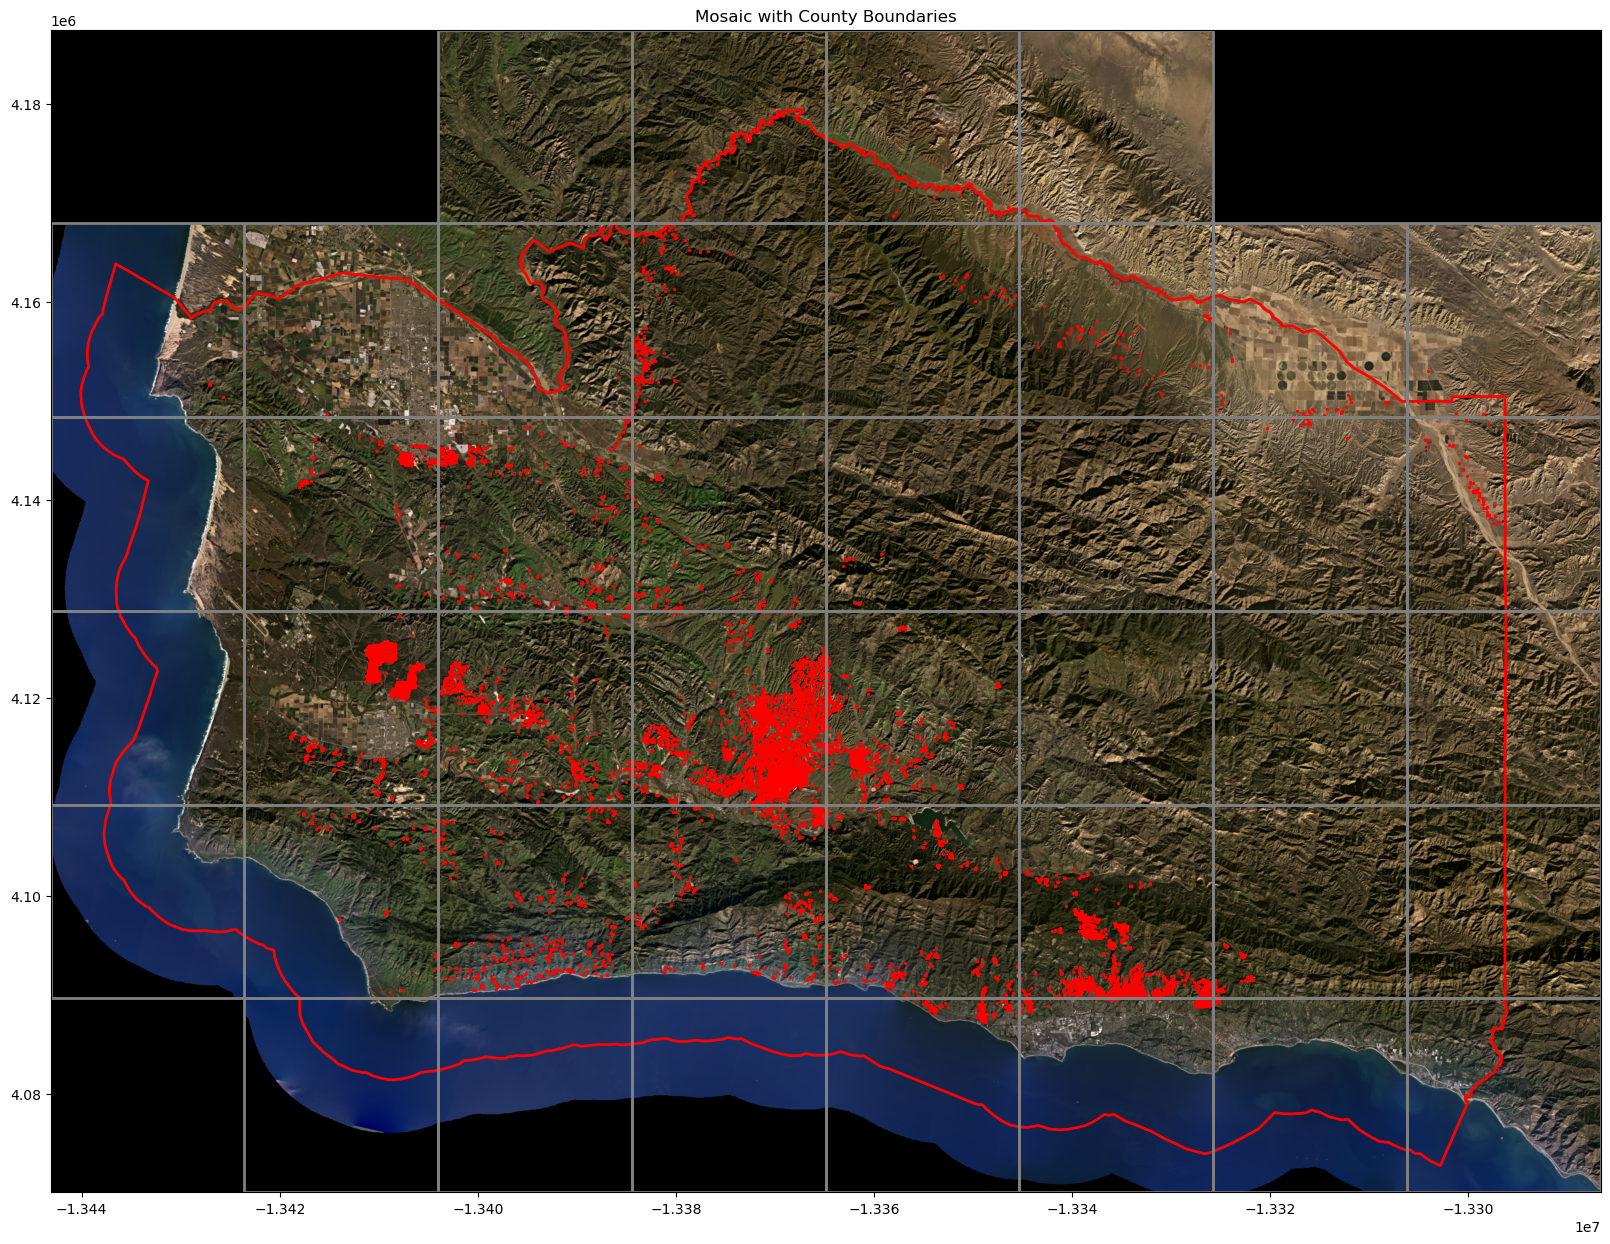

In [ ]:

# After creating the mosaic, update the metadata with the output transform and save it
meta.update({
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_trans,  # Use the transform from merge
})

# Save the final mosaic with spatial information
output_mosaic_path = "mosaic.tif"
with rasterio.open(output_mosaic_path, "w", **meta) as dst:
    dst.write(mosaic)

# Now you can plot everything together
fig, ax = plt.subplots(figsize=(20, 20))

# Plot the mosaic with proper spatial reference
with rasterio.open(output_mosaic_path) as src:
    show(src, ax=ax)

# Plot the county boundaries and quad boundaries
quad_df.to_crs(mercator).boundary.plot(ax=ax, edgecolor="grey", linewidth=2)
sb_county.to_crs(mercator).plot(ax=ax, color="none", edgecolor="red", linewidth=2)

# Plot the parcels inspection points
inspection_2022.to_crs(mercator).plot(ax=ax, markersize=2, color="red", label="2022 Inspections")

ax.set_title("Mosaic with County Boundaries")
plt.show()

In [ ]:
gbd_path = "/capstone/wildfire_prep/data-preparation/planet_download/data/parcel_boundaries/cbiinputs.gdb"
geodetic = "EPSG:4326"

parcels = gpd.read_file(gbd_path)
parcels = parcels.to_crs("EPSG:4326")
print("Parcels CRS:", parcels.crs)

Parcels CRS: EPSG:4326


<Axes: >

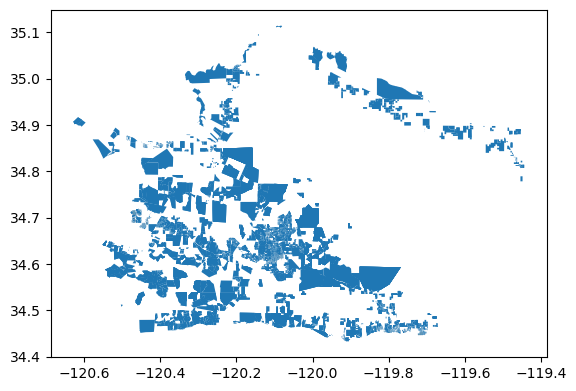

In [ ]:
parcels = parcels.to_crs(inspection_2022.crs)
inspected_parcels = gpd.sjoin(parcels, inspection_2022, how="inner", predicate="contains")
inspected_parcels.plot()

In [ ]:
# Open the raster file
with rasterio.open("mosaic.tif") as src:
    # Check if CRS matches
    if inspected_parcels.crs != src.crs:
        inspected_parcels = inspected_parcels.to_crs(src.crs)
    
    # Extract geometries in a format compatible with rasterio.mask.mask
    geoms = [feature for feature in inspected_parcels.geometry]

    # Clip the raster using the geometry from the shapefile
    out_image, out_transform = mask(src, geoms, crop=True)
    
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

# Save the clipped raster to a new file
with rasterio.open("mosaic_clipped_2022.tif", "w", **out_meta) as dest:
    dest.write(out_image)

In [ ]:
fig, ax = plt.subplots(figsize=(20, 20))

# Plot the mosaic with proper spatial reference
with rasterio.open("mosaic_clipped_2022.tif") as src:
    show(src, ax=ax)

# Plot the county boundaries and quad boundaries
quad_df.to_crs(mercator).boundary.plot(ax=ax, edgecolor="grey", linewidth=0.5)
sb_county.to_crs(mercator).plot(ax=ax, color="none", edgecolor="blue", linewidth=0.5)

# Plot the parcels inspection points
inspection_2022.to_crs(mercator).plot(ax=ax, markersize=.5, color="orange", label="2022 Inspections")

ax.set_title("Mosaic 2022 Clipped by Parcel Boundaries")
plt.show()

NameError: name 'plt' is not defined